# Tutorial 8 — A/B test of response times

## 1. Problem / context

Operations compares two API server configurations using `response_times.csv`:

- `server_a_ms` and `server_b_ms` are **independent** samples: different requests on A and on B.
- `server_b_paired_ms` is a **paired** measurement: the same request replayed on B.

Two columns in a spreadsheet do not decide the design. The observational unit and how the times were obtained decide the method.

Brooks Chapter 8 is the theory. This tutorial follows its six-step order on one traffic study.

We also define an SLA failure **before** seeing the tests: a response above 140 ms is a failure. That threshold comes from the service target, not from a search over the data.

## 2. What we will compute

Comparison order, fixed in advance: a **reduction** on B is an improvement, so the mean difference is

$$
\delta=\mu_A-\mu_B
$$

in milliseconds. Positive $\delta$ means A is slower.

- Independent quantitative groups: **Welch's** $t$ procedure is the default. We do not run Levene's test to switch automatically between pooled and Welch analyses.
- Paired quantitative measurements: analyse the within-pair differences $d_i=A_i-B_{i,\mathrm{paired}}$. The paired $t$ procedure is a one-sample analysis of those differences.
- Independent binary outcomes: SLA-failure proportions $p_A-p_B$, with a difference interval. Relative risk is an optional supplement; it is not an odds ratio.

Random sampling supports generalisation to a population. Random assignment supports a causal comparison of configurations. These data are a designed A/B comparison of two configurations on observed traffic; we will not claim more than the design supports.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t, ttest_ind, ttest_rel, norm

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "response_times.csv")
a = df["server_a_ms"].to_numpy()
b = df["server_b_ms"].to_numpy()
b_paired = df["server_b_paired_ms"].to_numpy()
print(df.head())
print(df[["server_a_ms", "server_b_ms", "server_b_paired_ms"]].describe())


   request_id  server_a_ms  server_b_ms  server_b_paired_ms
0           1       133.91       149.61              125.64
1           2       126.86       124.67              125.09
2           3       132.98       119.45              118.47
3           4       107.81        91.04               90.20
4           5       128.54        91.07              120.16
       server_a_ms  server_b_ms  server_b_paired_ms
count    60.000000    60.000000           60.000000
mean    118.533833   110.954167          111.156833
std      14.031857    16.925346           13.610336
min      65.540000    75.600000           61.460000
25%     109.962500   100.440000          101.527500
50%     119.775000   111.055000          113.890000
75%     127.700000   120.617500          119.905000
max     147.770000   156.370000          145.580000


### Independent groups: Welch


In [2]:
na, nb = a.size, b.size
diff = a.mean() - b.mean()
se_w = np.sqrt(a.var(ddof=1) / na + b.var(ddof=1) / nb)
res_w = ttest_ind(a, b, equal_var=False, alternative="two-sided")
df_w = res_w.df
ci_w = t.interval(0.95, df=df_w, loc=diff, scale=se_w)
print(f"n_A = {na}, n_B = {nb}")
print(f"mean A = {a.mean():.2f} ms, mean B = {b.mean():.2f} ms")
print(f"Welch estimate of µ_A − µ_B = {diff:.2f} ms")
print(f"SE = {se_w:.2f} ms, df ≈ {df_w:.2f}")
print(res_w)
print("95% Welch CI (ms):", tuple(np.round(ci_w, 2)))


n_A = 60, n_B = 60
mean A = 118.53 ms, mean B = 110.95 ms
Welch estimate of µ_A − µ_B = 7.58 ms
SE = 2.84 ms, df ≈ 114.08
TtestResult(statistic=np.float64(2.670485469274359), pvalue=np.float64(0.00868070086341238), df=np.float64(114.08219240963783))
95% Welch CI (ms): (np.float64(1.96), np.float64(13.2))


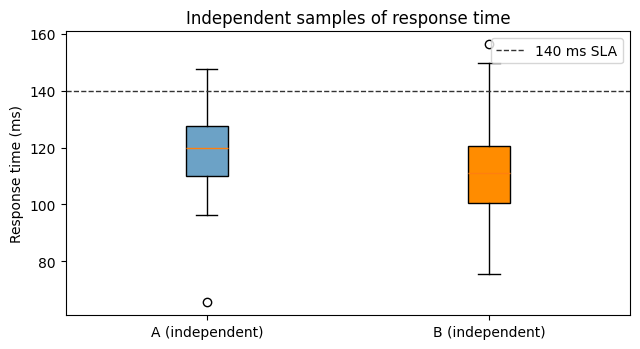

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
bp = ax.boxplot([a, b], patch_artist=True)
ax.set_xticklabels(["A (independent)", "B (independent)"])
for patch, color in zip(bp["boxes"], ["#6CA2C6", "#FF8C00"]):
    patch.set_facecolor(color)
ax.axhline(140, color="0.2", linestyle="--", linewidth=1, label="140 ms SLA")
ax.set_ylabel("Response time (ms)")
ax.set_title("Independent samples of response time")
ax.legend()
plt.tight_layout()
plt.show()


Cohen's $d$ is optional. The decision-relevant number is the difference in **milliseconds**, with its interval.


In [4]:
s_pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
print("optional Cohen d (pooled SD):", diff / s_pooled)


optional Cohen d (pooled SD): 0.4875617103371119


Do **not** test A against 140 ms, test B against 140 ms, and then compare the two significance decisions. Test the difference directly, as above.

### Paired measurements: the same requests

Pairing is valid only because each row is the **same request**. Pairing unrelated requests is invalid. Treating genuine pairs as independent throws away the design.


In [5]:
d = a - b_paired
print(f"mean paired difference A − B = {d.mean():.2f} ms, s_d = {d.std(ddof=1):.2f} ms")
res_p = ttest_rel(a, b_paired, alternative="two-sided")
se_d = d.std(ddof=1) / np.sqrt(d.size)
ci_d = t.interval(0.95, df=d.size - 1, loc=d.mean(), scale=se_d)
print(res_p)
print("95% CI for µ_D (ms):", tuple(np.round(ci_d, 2)))


mean paired difference A − B = 7.38 ms, s_d = 5.79 ms
TtestResult(statistic=np.float64(9.875297040509599), pvalue=np.float64(4.1058562413548425e-14), df=np.int64(59))
95% CI for µ_D (ms): (np.float64(5.88), np.float64(8.87))


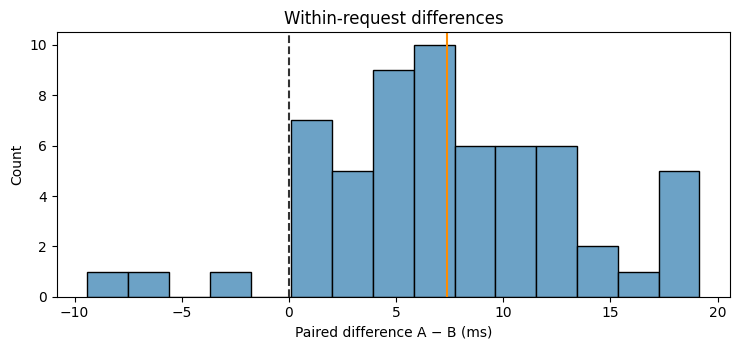

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(d, bins=15, color="#6CA2C6", edgecolor="black")
ax.axvline(0, color="0.2", linestyle="--")
ax.axvline(d.mean(), color="#FF8C00")
ax.set_xlabel("Paired difference A − B (ms)")
ax.set_ylabel("Count")
ax.set_title("Within-request differences")
plt.tight_layout()
plt.show()


The paired $t$ test is `ttest_1samp(d, popmean=0)` in another costume.

Pause: which analysis answers “different requests on two servers”, and which answers “the same request replayed”?

### Independent proportions: SLA failures

A response above 140 ms is an SLA failure. The parameter is $p_A-p_B$.


In [7]:
fail_a = (a > 140).astype(int)
fail_b = (b > 140).astype(int)
x1, x2 = int(fail_a.sum()), int(fail_b.sum())
p1, p2 = x1 / na, x2 / nb
delta = p1 - p2
se_p = np.sqrt(p1 * (1 - p1) / na + p2 * (1 - p2) / nb)
z = norm.ppf(0.975)
ci_p = (delta - z * se_p, delta + z * se_p)
p_pool = (x1 + x2) / (na + nb)
se0 = np.sqrt(p_pool * (1 - p_pool) * (1 / na + 1 / nb))
z_obs = delta / se0
p_two = 2 * norm.sf(np.abs(z_obs))
rr = p1 / p2
print(f"failures A: {x1}/{na} = {p1:.3f}")
print(f"failures B: {x2}/{nb} = {p2:.3f}")
print(f"risk difference p_A − p_B = {delta:.3f}")
print("95% CI (percentage points / 100):", tuple(np.round(ci_p, 3)))
print(f"z = {z_obs:.3f}, two-sided p ≈ {p_two:.4g}")
print(f"relative risk p_A / p_B = {rr:.3f}  (not an odds ratio)")


failures A: 3/60 = 0.050
failures B: 4/60 = 0.067
risk difference p_A − p_B = -0.017
95% CI (percentage points / 100): (np.float64(-0.1), np.float64(0.067))
z = -0.389, two-sided p ≈ 0.6969
relative risk p_A / p_B = 0.750  (not an odds ratio)


The interval uses **separate** estimated variances. The test pools under $H_0:p_A=p_B$. Those two standard errors are not interchangeable.

## 4. Interpretation

Follow the Chapter 8 six-step order: units and comparison order; independent versus paired; plots; estimate and interval; hypotheses, statistic, and $p$; magnitude in ms or percentage points, with design limits.

Here the independent-samples estimate is about 7.6 ms, with a 95% interval from about 2.0 to 13.2 ms. Whether a difference in that range matters is an operational judgement. More generally, a statistically detectable shift can be irrelevant, while an important shift can remain uncertain in a small study. The interval, not the $p$-value, carries that information.

These independent samples compare two configurations on observed traffic. A causal claim that “switching to B will reduce latency in production” needs a design that supports it (including how requests were assigned). Pairing answers a different question: the same request under two configurations.

## 5. Common mistakes / things to notice

- Using Levene’s test as an automatic pooled-versus-Welch switch.
- Running `ttest_ind` on paired rows, or pairing unrelated requests.
- Testing each group separately and comparing the two $p$-values.
- Reporting Cohen’s $d$ instead of milliseconds.
- Calling a risk difference an odds ratio, or a relative risk an odds ratio.
- Treating a significant A/B result as proof of a production-wide causal effect without the design.

**Conclusion:** Match the test to the design. Welch estimates $\mu_A-\mu_B$ for independent traffic; the paired $t$ estimates the mean within-request difference; the SLA comparison estimates $p_A-p_B$ in percentage points. In every case report the interval in engineering units and separate statistical evidence from practical importance.
